In [1]:
%run ../scripts/notebook_settings_lean.py
from scipy import stats
from horizonplot import horizonplot

In [2]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering.txt", sep =" ")

In [3]:
def length_to_windows(length_df, window_size=100000):
    pops = sorted(length_df["pop"].unique())
    window_l = list(range(length_df.pos.values[0], length_df.end_pos.values[-1], window_size))
    overall_dict = {"windows": window_l}
    for p in pops:
        overall_dict[p] = np.zeros(len(window_l))
    for i in range(len(window_l)):
        w = window_l[i]
        # Finding all paintings that start in this window.
        s_df = length_df.loc[(length_df.pos >= w) & (length_df.pos < w+window_size)]
        for index, row in s_df.iterrows():
            # x decides how many windows it should go beyond the current.
            # if x==0, it both starts and ends in the same window
            x = (row.pos-w+row.paint_length)//window_size
            if x == 0:
                overall_dict[row["pop"]][i] += int(row.paint_length)
            # Otherwise, the current window is filled from row.pos to window end
            else:
                overall_dict[row["pop"]][i] += int((w+window_size)-row.pos)
                # Then iterated for each full window (which is all windows < x)
                for s in range(x-1):
                    overall_dict[row["pop"]][i+1+s] += int(window_size)
                # Then finally added the ending window
                # print(row.paint_length+row.pos, (w+x*window_size), x, w)
                overall_dict[row["pop"]][i+x] += int(row.paint_length+row.pos-(w+x*window_size))
    df = pd.DataFrame(overall_dict)
    return df

def generate_spot_df(single_p_df, map_dict):
    single_p_df["pop"] = single_p_df["paint"].map(map_dict)
    shift_spots = (single_p_df["pop"] != single_p_df["pop"].shift())
    #df based on this subset
    spot_df = single_p_df.loc[shift_spots].copy()
    #Finding the start of the next painting, by removing the first pos and adding the last snp.
    #And then calculating the difference.
    spot_df["paint_length"] = (np.append(spot_df["pos"][1:].values, single_p_df.iloc[-1]["pos"])-spot_df["pos"].values)
    spot_df["end_pos"] = (np.append(spot_df["pos"][1:].values, single_p_df.iloc[-1]["pos"])-1)
    return spot_df

def create_paint_df_lengths(paintfile, idfile):
    #various supplemental dataframes/lists
    end_pos = pos_list.values[-1]
    
    map_dict = {}
    for i, row in idfile.iterrows():
        map_dict[row.ID_index*2+1] = row["pop"]
        map_dict[row.ID_index*2+2] = row["pop"]

    df_l = []
    f = open(paintfile, "r")
    ad_lines = f.readlines()
    ind = ""
    hap = ""
    for p_num in range(1, len(ad_lines)):
        l = ad_lines[p_num].strip().split(" ")
        if l[0] == "HAP":
            ind = l[2]
            if hap == 1:
                hap = 2
            else:
                hap = 1
        else:
            paint_line = l[1:]
            single_p_df = pd.DataFrame(data={"pos": pos_list, "paint": paint_line})
            single_p_df = single_p_df.astype(int)
            spot_df = generate_spot_df(single_p_df, map_dict)
            spot_df["individual"] = ind
            spot_df["haplotype"] = hap
            df_l.append(spot_df)
    all_df = pd.concat(df_l)
    return all_df

In [4]:
recomb_map_path = "/home/eriks/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021/chr{}/chr{}.females.recombfile"
idfile_path = "/home/eriks/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021/idfile_8_cluster_females.ids"
idfile = pd.read_csv(idfile_path, sep=" ", names=["PGDP_ID", "pop", "inclusion"])
idfile["ID_index"] = idfile.index
recomb_map = pd.read_csv(recomb_map_path.format("X", "X"), sep=" ")
pos_list = recomb_map["start.pos"]

In [5]:
idfile_path = "/home/eriks/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021/included_females.ids"
idfile = pd.read_csv(idfile_path, sep=" ", names=["PGDP_ID", "pop", "inclusion"])
idfile["ID_index"] = idfile.index
recomb_map_path = "/home/eriks/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021/chr{}/chr{}.females.v2.recombfile"

os.makedirs("../steps/paint_summary/", exist_ok=True)
chrom_list = ["X"]
window_length = 100000
for chrom in chrom_list:
    recomb_map = pd.read_csv(recomb_map_path.format(chrom, chrom), sep=" ")
    pos_list = recomb_map["start.pos"]
    for population in sorted(idfile["pop"].unique()):
        print(population)

anubis_ethiopia
anubis_tanzania
cyno_central
cyno_western
hamadryas
kindae
papio
ursinus


In [6]:
idfile["pop"]

0     cyno_central
1     cyno_central
2           kindae
3           kindae
4        hamadryas
          ...     
93          kindae
94          kindae
95          kindae
96          kindae
97          kindae
Name: pop, Length: 98, dtype: object

In [7]:
idfile_path = "/home/eriks/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021/idfile_8_cluster_females.ids"
idfile = pd.read_csv(idfile_path, sep=" ", names=["PGDP_ID", "pop", "inclusion"])
idfile["ID_index"] = idfile.index
recomb_map_path = "/home/eriks/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021/chr{}/chr{}.females.v2.recombfile"

os.makedirs("../steps/paint_summary/", exist_ok=True)
chrom_list = [] # ["X"]
window_length = 100000
IDfile_mapping = dict(zip(idfile.ID_index, idfile.PGDP_ID))

for chrom in chrom_list:
    recomb_map = pd.read_csv(recomb_map_path.format(chrom, chrom), sep=" ")
    pos_list = recomb_map["start.pos"]
    for ID in sorted(idfile.loc[(idfile.inclusion == 1)].ID_index):
        PDGP_ID = IDfile_mapping[ID]
        print(ID, PDGP_ID)
        pop_path = "/home/eriks/baboondiversity/people/eriks/second_analysis_baboons/steps/" \
                        "chrX_females_lai/chromopaintings/copy{}.samples.out" \
                        .format(ID)
        length_df = create_paint_df_lengths(pop_path, idfile)
        name = population+"_chr"+chrom+"chrX_lai"+PDGP_ID+"_hap.txt"
        window_df_1 = length_to_windows(length_df.loc[(length_df.haplotype==1)], window_size=window_length)
        window_df_2 = length_to_windows(length_df.loc[(length_df.haplotype==2)], window_size=window_length)
        window_df_1["haplotype"] = PDGP_ID+"_hap1"
        window_df_2["haplotype"] = PDGP_ID+"_hap2"
        window_df = pd.concat([window_df_1, window_df_2])
        window_df["PDGP_ID"] = PDGP_ID
        window_df.to_csv("../steps/paint_summary/"+name, sep=" ", index=False)

In [8]:
idfile

,PGDP_ID,pop,inclusion,ID_index
0,Sci_16066,cyno_central,1,0
1,Sci_16098,cyno_central,1,1
2,Sci_34449,kindae,1,2
3,Sci_34474,kindae,1,3
4,Sci_97074,hamadryas,1,4
...,...,...,...,...
93,PD_0788,kindae,1,93
94,PD_0789,kindae,1,94
95,PD_0790,kindae,1,95
96,PD_0791,kindae,1,96


In [54]:

idfile["ID_index"] = idfile.index
IDfile_mapping = dict(zip(idfile.ID_index, idfile.PGDP_ID))
df_l = []
for ID in sorted(idfile.loc[(idfile.inclusion == 1)].ID_index):
    for chrom in ["X"]:
        PDGP_ID = IDfile_mapping[ID]
        name = population+"_chr"+chrom+"chrX_lai"+PDGP_ID+"_hap.txt"
        ind_df = pd.read_csv("../steps/paint_summary/"+name, sep=" ")
        ind_df["chrom"] = chrom
        df_l.append(ind_df)
a_c_df = pd.concat(df_l)

In [50]:
a_c_df_mean = a_c_df.groupby(["PDGP_ID", "haplotype", "chrom", "windows"]).mean().reset_index()
a_c_df_mean["north"] = a_c_df_mean.hamadryas+a_c_df_mean.papio
a_c_df_mean["norm_north"] = (a_c_df_mean.north-a_c_df_mean.iloc[:,4:8].sum(axis=1)/2)
a_c_df_mean["start"] = a_c_df_mean["windows"]
a_c_df_mean

,PDGP_ID,haplotype,chrom,windows,hamadryas,kindae,papio,ursinus,start,north,norm_north
0,PD_0199,PD_0199_hap1,X,37,663621.0,91150.0,189860.0,55369.0,37,853481.0,353481.0
1,PD_0199,PD_0199_hap1,X,100037,611998.0,230286.0,74296.0,83420.0,100037,686294.0,186294.0
2,PD_0199,PD_0199_hap1,X,200037,935699.0,3910.0,57372.0,3019.0,200037,993071.0,493071.0
3,PD_0199,PD_0199_hap1,X,300037,988242.0,2408.0,9350.0,0.0,300037,997592.0,497592.0
4,PD_0199,PD_0199_hap1,X,400037,724353.0,48681.0,2803.0,224163.0,400037,727156.0,227156.0
...,...,...,...,...,...,...,...,...,...,...,...
281647,Sci_97074,Sci_97074_hap2,X,143200037,1000000.0,0.0,0.0,0.0,143200037,1000000.0,500000.0
281648,Sci_97074,Sci_97074_hap2,X,143300037,1000000.0,0.0,0.0,0.0,143300037,1000000.0,500000.0
281649,Sci_97074,Sci_97074_hap2,X,143400037,997913.0,0.0,2087.0,0.0,143400037,1000000.0,500000.0
281650,Sci_97074,Sci_97074_hap2,X,143500037,1000000.0,0.0,0.0,0.0,143500037,1000000.0,500000.0


In [ ]:
anubis = a_c_df.loc[a_c_df.PDGP_ID.isin(idfile.loc[idfile["pop"] == "anubis_tanzania"].PGDP_ID)]

<Axes: xlabel='norm_north', ylabel='Count'>

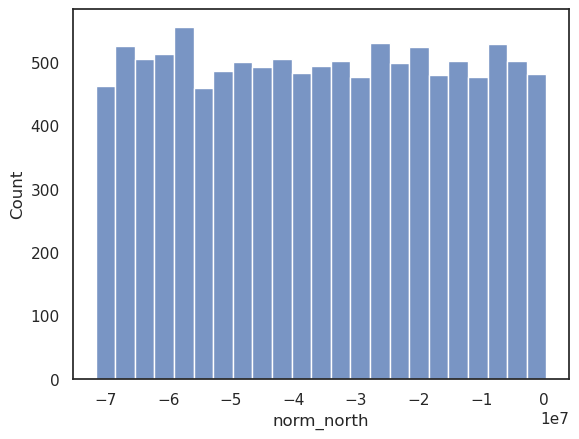

In [51]:
sns.histplot(chrX.norm_north)

In [ ]:
fig = horizonplot(a_c_df, 'norm_north', width=2, col='chrom', row='PDGP_ID', size=0.3, aspect=100)
fig.savefig("../steps/paint_plots/all_inds_lai.pdf", dpi=300, format="pdf")

In [ ]:
chrX = anubis.loc[anubis.chrom == "X"]
fig = horizonplot(chrX, 'norm_north', width=2, col='chrom', row='PDGP_ID', size=0.3, aspect=100)
fig.savefig("../steps/paint_plots/ChrX_anubis_tanzania_lai.pdf", dpi=300, format="pdf")

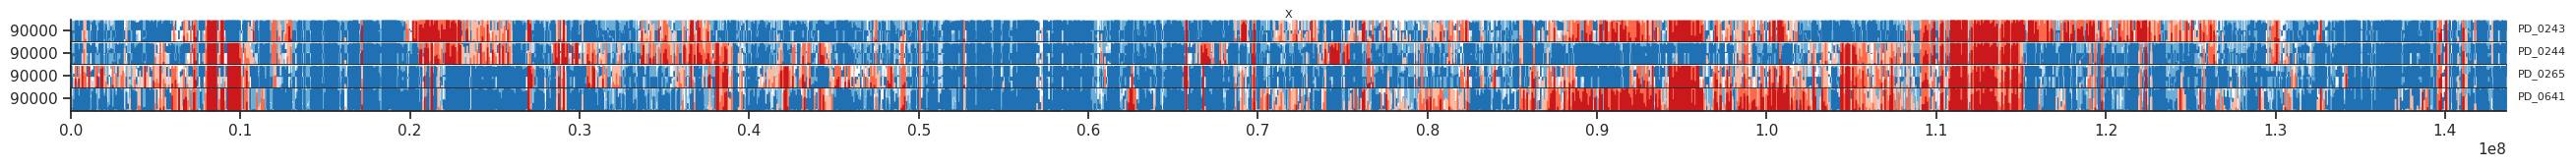

In [52]:
trangire_ID_subset = meta_data_samples.loc[meta_data_samples.Origin.isin(["Tarangire, Tanzania"])].PGDP_ID
anubis_subset = a_c_df_mean.loc[a_c_df_mean.PDGP_ID.isin(trangire_ID_subset)]
chrX = anubis_subset.loc[anubis_subset.chrom == "X"]
fig = horizonplot(chrX, 'norm_north', width=2, col='chrom', row='PDGP_ID', size=0.3, aspect=100)

In [173]:
olive_IDs_subset = meta_data_samples.loc[meta_data_samples.Origin.isin(["Tarangire, Tanzania",
                                                                        "Serengeti, Tanzania",
                                                                        "Gombe, Tanzania"])].PGDP_ID
anubis_subset = a_c_df.loc[a_c_df.PDGP_ID.isin(olive_IDs_subset)]

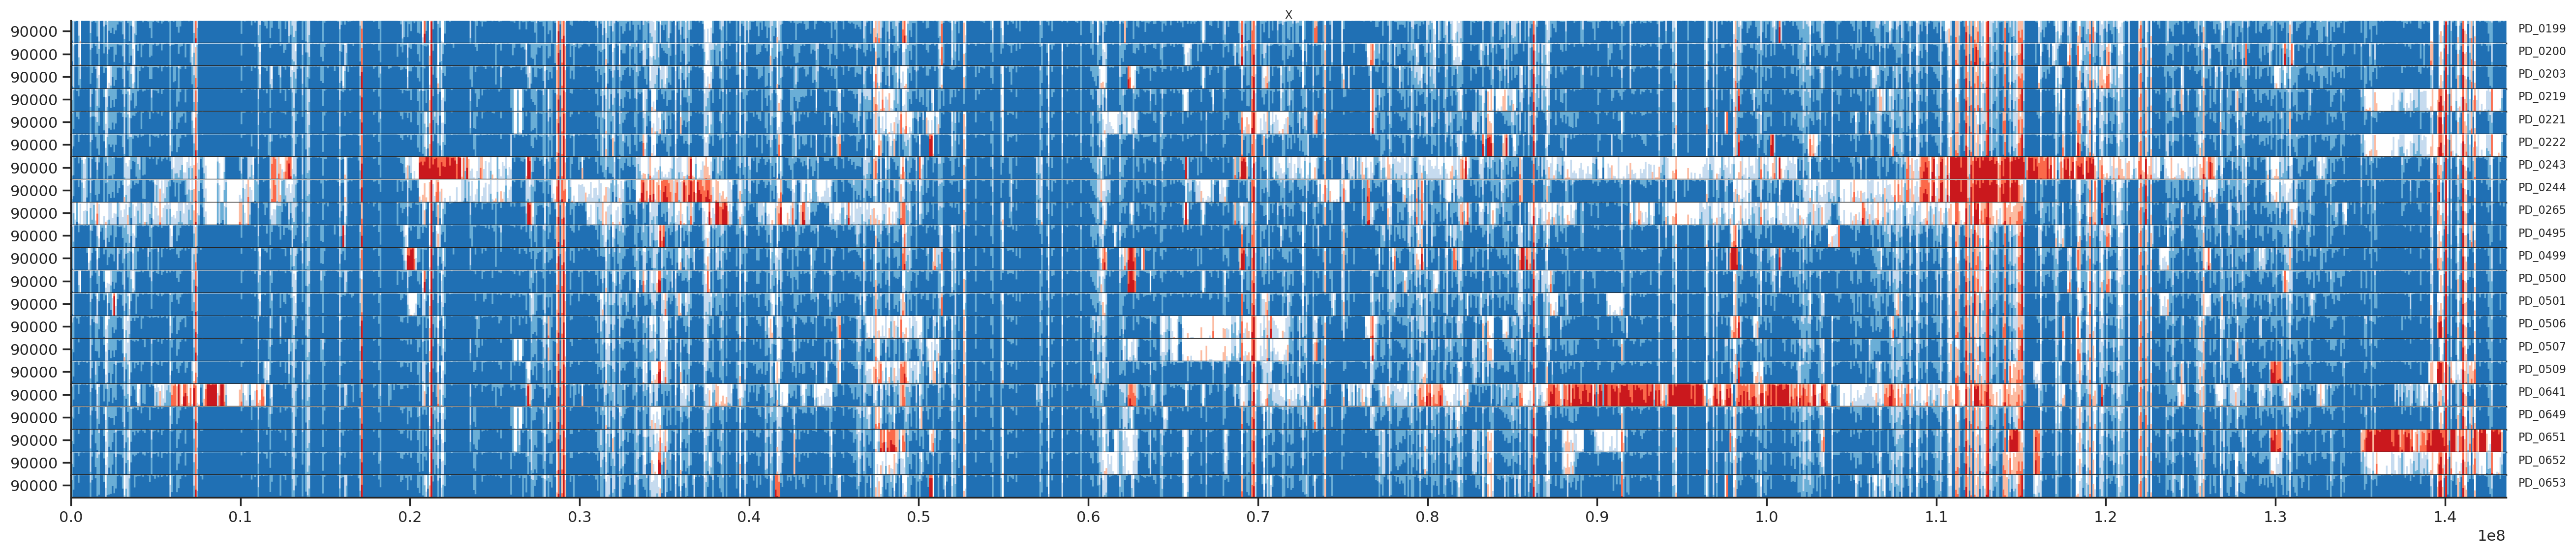

In [174]:
chrX = anubis_subset.loc[anubis_subset.chrom == "X"]
fig = horizonplot(chrX, 'norm_north', width=2, col='chrom', row='PDGP_ID', size=0.3, aspect=100)
fig.savefig("../steps/paint_plots/ChrX_anubis_tanzania_subset_lai.pdf", dpi=300, format="pdf")

In [26]:
east_cyno = a_c_df.loc[a_c_df.PDGP_ID.isin(idfile.loc[idfile["pop"] == "cyno_central"].PGDP_ID)]

In [27]:
east_cyno

,PDGP_ID,chrom,windows,hamadryas,kindae,papio,ursinus,north,norm_north,start
14370,PD_0213,X,37,170291.0,458802.0,47243.0,323664.0,217534.0,-282466.0,37
14371,PD_0213,X,100037,330073.0,534586.0,2251.5,133089.5,332324.5,-167675.5,100037
14372,PD_0213,X,200037,45339.0,571610.0,24515.0,358536.0,69854.0,-430146.0,200037
14373,PD_0213,X,300037,238389.0,513460.5,113328.5,134822.0,351717.5,-148282.5,300037
14374,PD_0213,X,400037,43846.5,502920.0,4443.0,448790.5,48289.5,-451710.5,400037
...,...,...,...,...,...,...,...,...,...,...
136510,Sci_16098,X,143200037,39.0,999948.0,0.0,13.0,39.0,-499961.0,143200037
136511,Sci_16098,X,143300037,0.0,1000000.0,0.0,0.0,0.0,-500000.0,143300037
136512,Sci_16098,X,143400037,969.0,995274.0,513.0,3244.0,1482.0,-498518.0,143400037
136513,Sci_16098,X,143500037,145179.5,854662.5,0.0,158.0,145179.5,-354820.5,143500037


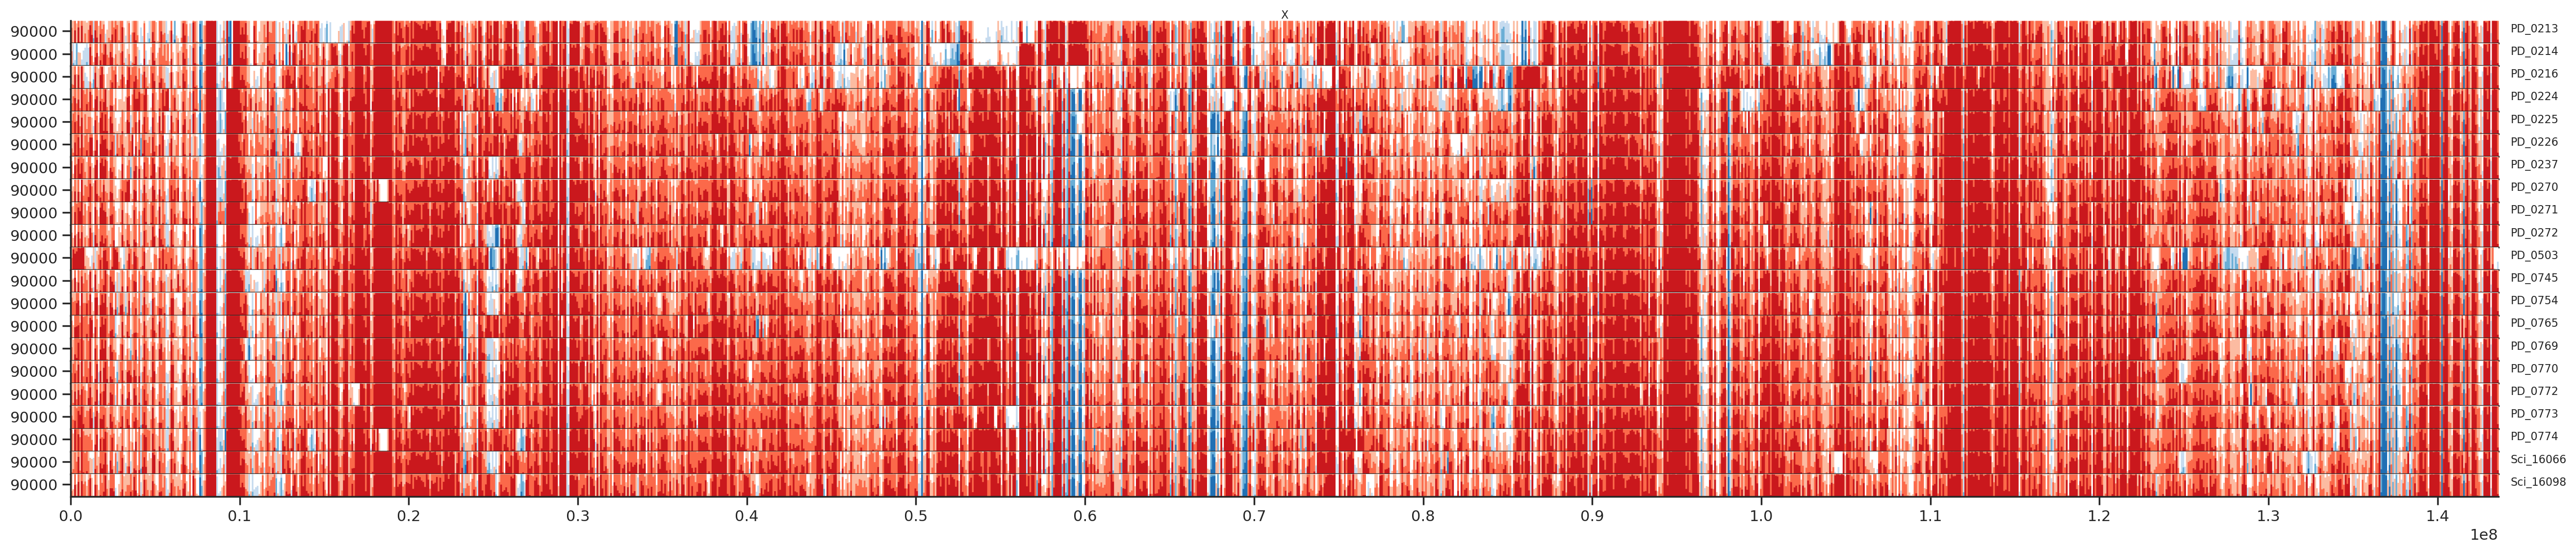

In [28]:
chrX = east_cyno.loc[east_cyno.chrom == "X"]
fig = horizonplot(chrX, 'norm_north', width=2, col='chrom', row='PDGP_ID', size=0.3, aspect=100)
fig.savefig("../steps/paint_plots/ChrX_eastern_cyno_lai.pdf", dpi=300, format="pdf")

Genecheck rerun

In [13]:
import geneinfo as gi

%env ftp_proxy http://proxy-default:3128
%env http_proxy http://proxy-default:3128
%env https_proxy http://proxy-default:3128

env: ftp_proxy=http://proxy-default:3128
env: http_proxy=http://proxy-default:3128
env: https_proxy=http://proxy-default:3128


In [14]:
a_c_df["percent_north"] = (a_c_df.north/a_c_df.iloc[:,3:7].sum(axis=1))
a_c_df

,PDGP_ID,chrom,windows,hamadryas,kindae,papio,ursinus,north,norm_north,start,percent_north
0,PD_0199,X,37,724067.0,92492.5,131843.5,51597.0,855910.5,355910.5,37,0.855911
1,PD_0199,X,100037,601933.5,243121.0,69123.0,85822.5,671056.5,171056.5,100037,0.671056
2,PD_0199,X,200037,934771.5,2688.5,60405.5,2134.5,995177.0,495177.0,200037,0.995177
3,PD_0199,X,300037,988791.5,1365.0,9843.5,0.0,998635.0,498635.0,300037,0.998635
4,PD_0199,X,400037,723558.5,46836.0,1631.5,227974.0,725190.0,225190.0,400037,0.725190
...,...,...,...,...,...,...,...,...,...,...,...
140821,Sci_97074,X,143200037,1000000.0,0.0,0.0,0.0,1000000.0,500000.0,143200037,1.000000
140822,Sci_97074,X,143300037,1000000.0,0.0,0.0,0.0,1000000.0,500000.0,143300037,1.000000
140823,Sci_97074,X,143400037,998842.0,114.5,1043.5,0.0,999885.5,499885.5,143400037,0.999885
140824,Sci_97074,X,143500037,1000000.0,0.0,0.0,0.0,1000000.0,500000.0,143500037,1.000000


In [15]:
olive_IDs = meta_data_samples.loc[meta_data_samples.C_origin == "Anubis, Tanzania"].PGDP_ID
east_yellow_IDs = meta_data_samples.loc[meta_data_samples.C_origin == "Cynocephalus, Central Tanzania"].PGDP_ID

In [16]:
meta_data_samples.loc[(meta_data_samples.C_origin == "Cynocephalus, Central Tanzania")
                      & (meta_data_samples.Sex == "F")].Origin

0        Mikumi, Tanzania
1        Mikumi, Tanzania
24        Ruaha, Tanzania
25        Ruaha, Tanzania
27        Ruaha, Tanzania
35     Udzungwa, Tanzania
36     Udzungwa, Tanzania
37     Udzungwa, Tanzania
48       Selous, Tanzania
61       Mikumi, Tanzania
62       Mikumi, Tanzania
63       Mikumi, Tanzania
87        Ruaha, Tanzania
177      Mikumi, Tanzania
186      Mikumi, Tanzania
197      Mikumi, Tanzania
201      Mikumi, Tanzania
202      Mikumi, Tanzania
204      Mikumi, Tanzania
205      Mikumi, Tanzania
206      Mikumi, Tanzania
Name: Origin, dtype: object

In [17]:
olive_tanzania = a_c_df.loc[a_c_df.PDGP_ID.isin(olive_IDs)]
olive_tanzania_mean = olive_tanzania.groupby("start").mean().reset_index()
eastern_yellow = a_c_df.loc[a_c_df.PDGP_ID.isin(east_yellow_IDs)]
eastern_yellow_mean = eastern_yellow.groupby("start").mean().reset_index()

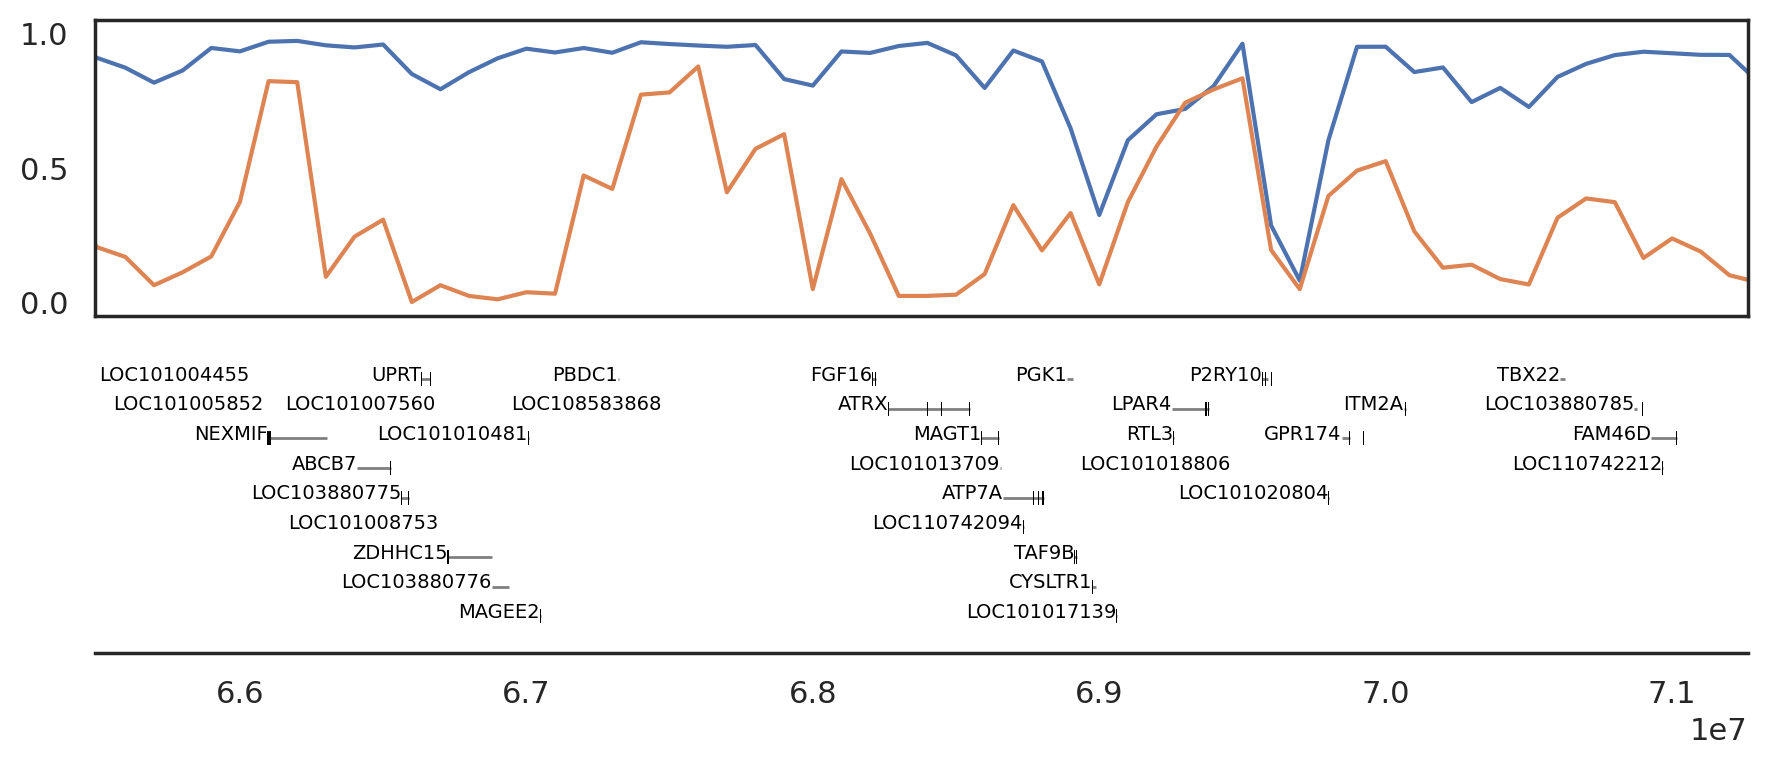

In [18]:
ax = gi.gene_plot('chrX', 66000000, 71000000, assembly='papAnu4', exact_exons=True, figsize=(9, 4))
roll_size = 1
#ax.plot(data=olive_mean.rolling(roll_size).mean(), x="windows", y="percent_north")
ax.plot(olive_tanzania_mean.start, olive_tanzania_mean["percent_north"])
ax.plot(eastern_yellow_mean.start, eastern_yellow_mean["percent_north"])
plt.tight_layout()

Reading in the rfmix data

In [19]:
def length_to_windows_rf(length_df, pops, window_size=100000):
    window_l = list(range(length_df.pos.values[0], length_df.end_pos.values[-1], window_size))
    overall_dict = {"windows": window_l}
    for p in pops:
        overall_dict[p] = np.zeros(len(window_l))
    for i in range(len(window_l)):
        w = window_l[i]
        # Finding all paintings that start in this window.
        s_df = length_df.loc[(length_df.pos >= w) & (length_df.pos < w+window_size)]
        for index, row in s_df.iterrows():
            # x decides how many windows it should go beyond the current.
            # if x==0, it both starts and ends in the same window
            x = (row.pos-w+row.length)//window_size
            if x == 0:
                overall_dict[row["reference"]][i] += int(row.length)
            # Otherwise, the current window is filled from row.pos to window end
            else:
                overall_dict[row["reference"]][i] += int((w+window_size)-row.pos)
                # Then iterated for each full window (which is all windows < x)
                for s in range(x-1):
                    overall_dict[row["reference"]][i+1+s] += int(window_size)
                # Then finally added the ending window
                # print(row.paint_length+row.pos, (w+x*window_size), x, w)
                overall_dict[row["reference"]][i+x] += int(row.length+row.pos-(w+x*window_size))
    df = pd.DataFrame(overall_dict)
    return df

def create_paint_df_ind_rf(df, ind, mapping, ns_map):
    d = {}
    d["pos"] = df.spos
    d["end_pos"] = df.epos -1
    d["length"] = df.epos - df.spos
    d["reference"] = df[ind].map(mapping)
    d["n/s"] = d["reference"].map(ns_map)
    d["individual"] = ind[:-2]
    d["haplotype"] = ind[-1:]
    return pd.DataFrame(d)

In [20]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering.txt", sep =" ")
rfmix_path = "/home/eriks/baboondiversity/people/eriks/second_analysis_baboons/steps/rfmix_females_gen50/"
input_file = rfmix_path + "chrX.msp.tsv"
chrX = pd.read_csv(input_file, sep = "\t", header=1)
file = open(input_file, 'r')
line1 = file.readline()
file.close()

In [21]:
number_subpop_mapping = {}
for subpop in line1.strip().split("\t"):
    # Splitting to create lists containing two values - subpop and number.
    subpop_number = subpop.split(": ")[-1].split("=")
    number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
# North is 1, South is 0
north_south_mapping = {'Hamadryas, Ethiopia': 1, 'Papio, Senegal': 1, 'Kindae, Zambia': 0, 'Ursinus, Zambia': 0}

In [22]:
df_l = []
for hap in chrX.columns[6:]:
    df_l.append(create_paint_df_ind_rf(chrX, hap, number_subpop_mapping, north_south_mapping))
length_df_X_rf = pd.concat(df_l)

In [23]:
length_df_X_rf

,pos,end_pos,length,reference,n/s,individual,haplotype
0,37,102015,101979,"Kindae, Zambia",0,Sci_16066,0
1,102016,288632,186617,"Kindae, Zambia",0,Sci_16066,0
2,288633,369747,81115,"Kindae, Zambia",0,Sci_16066,0
3,369748,386412,16665,"Kindae, Zambia",0,Sci_16066,0
4,386413,416213,29801,"Kindae, Zambia",0,Sci_16066,0
...,...,...,...,...,...,...,...
1392,142676468,142696008,19541,"Ursinus, Zambia",0,PD_0774,1
1393,142696009,142764121,68113,"Ursinus, Zambia",0,PD_0774,1
1394,142764122,142877353,113232,"Ursinus, Zambia",0,PD_0774,1
1395,142877354,142906818,29465,"Kindae, Zambia",0,PD_0774,1


In [25]:
df_l = []
for ID in length_df_X_rf.individual.unique():
    ID_df = length_df_X_rf.loc[length_df_X_rf.individual == ID]
    window_ID_df = length_to_windows_rf(ID_df, sorted(length_df_X_rf["reference"].unique()))
    window_ID_df["PDGP_ID"] = ID
    #print(ID)
    df_l.append(window_ID_df)
window_df_rf = pd.concat(df_l)

In [26]:
window_df_rf["percent_north"] = ((window_df_rf["Hamadryas, Ethiopia"]+window_df_rf["Papio, Senegal"])/window_df_rf.iloc[:,1:5].sum(axis=1))

In [27]:
a_c_df

,PDGP_ID,chrom,windows,hamadryas,kindae,papio,ursinus,north,norm_north,start,percent_north
0,PD_0199,X,37,724067.0,92492.5,131843.5,51597.0,855910.5,355910.5,37,0.855911
1,PD_0199,X,100037,601933.5,243121.0,69123.0,85822.5,671056.5,171056.5,100037,0.671056
2,PD_0199,X,200037,934771.5,2688.5,60405.5,2134.5,995177.0,495177.0,200037,0.995177
3,PD_0199,X,300037,988791.5,1365.0,9843.5,0.0,998635.0,498635.0,300037,0.998635
4,PD_0199,X,400037,723558.5,46836.0,1631.5,227974.0,725190.0,225190.0,400037,0.725190
...,...,...,...,...,...,...,...,...,...,...,...
140821,Sci_97074,X,143200037,1000000.0,0.0,0.0,0.0,1000000.0,500000.0,143200037,1.000000
140822,Sci_97074,X,143300037,1000000.0,0.0,0.0,0.0,1000000.0,500000.0,143300037,1.000000
140823,Sci_97074,X,143400037,998842.0,114.5,1043.5,0.0,999885.5,499885.5,143400037,0.999885
140824,Sci_97074,X,143500037,1000000.0,0.0,0.0,0.0,1000000.0,500000.0,143500037,1.000000


In [28]:
window_df_rf.loc[window_df_rf.PDGP_ID == "PD_0765"]

,windows,"Hamadryas, Ethiopia","Kindae, Zambia","Papio, Senegal","Ursinus, Zambia",PDGP_ID,percent_north
0,37,0.0,200000.0,0.0,0.0,PD_0765,0.0
1,100037,0.0,200000.0,0.0,0.0,PD_0765,0.0
2,200037,0.0,200000.0,0.0,0.0,PD_0765,0.0
3,300037,0.0,200000.0,0.0,0.0,PD_0765,0.0
4,400037,0.0,154962.0,0.0,45038.0,PD_0765,0.0
...,...,...,...,...,...,...,...
1432,143200037,0.0,200000.0,0.0,0.0,PD_0765,0.0
1433,143300037,0.0,200000.0,0.0,0.0,PD_0765,0.0
1434,143400037,0.0,200000.0,0.0,0.0,PD_0765,0.0
1435,143500037,0.0,200000.0,0.0,0.0,PD_0765,0.0


In [29]:
len(a_c_df.PDGP_ID.unique()), len(window_df_rf.PDGP_ID.unique())

(98, 75)

In [30]:
from scipy.stats.stats import pearsonr   

In [31]:
# Rf subset does not contain reference populations, 
ID_l, corr_l, pval_l = [], [], []
for ID in window_df_rf.PDGP_ID.unique():
    chromopainter_subset = a_c_df.loc[a_c_df.PDGP_ID == ID].reset_index()
    rf_subset = window_df_rf.loc[window_df_rf.PDGP_ID == ID].reset_index()
    bool_check = (rf_subset.percent_north.isna() | chromopainter_subset.percent_north.isna())
    chromopainter_subset = chromopainter_subset.loc[~bool_check]
    rf_subset = rf_subset.loc[~bool_check]
    #print(ID, bool_check.sum())
    ID_l.append(ID)
    corr_calc = pearsonr(x=chromopainter_subset.percent_north, y=rf_subset.percent_north)
    corr_l.append(corr_calc[0])
    pval_l.append(corr_calc[1])
    #print(ID, corr_calc[0], corr_calc[1])
corr_df = pd.DataFrame({"PDGP_ID": ID_l, "correlation": corr_l, "P-value": pval_l})

/home/eriks/miniconda3/envs/baboondiversity/lib/python3.7/site-packages/scipy/stats/stats.py:4023: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())


In [32]:
olive_IDs = meta_data_samples.loc[meta_data_samples.C_origin == "Anubis, Tanzania"].PGDP_ID
east_yellow_IDs = meta_data_samples.loc[meta_data_samples.C_origin == "Cynocephalus, Central Tanzania"].PGDP_ID

Text(0.5, 1.0, 'Correlation between rfmix and Chromopainter')

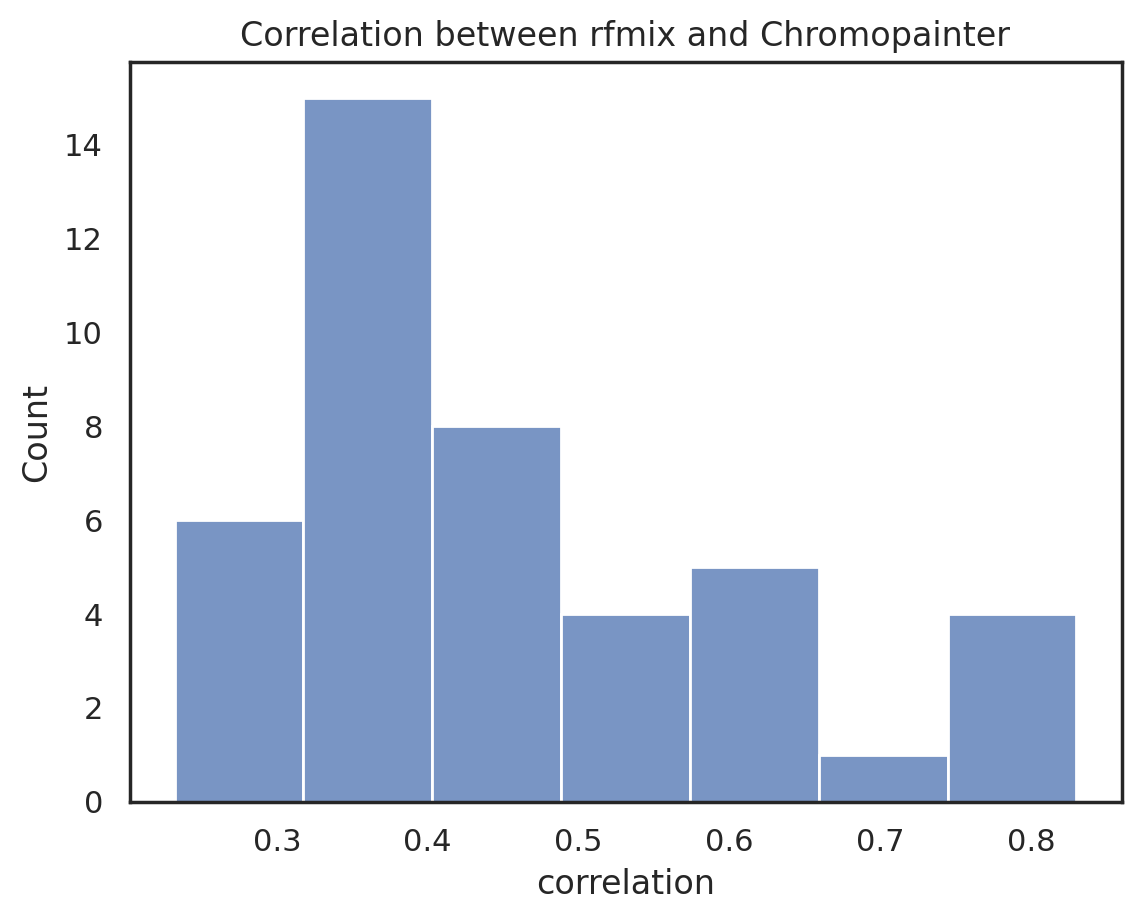

In [33]:
g = sns.histplot(data=corr_df.loc[corr_df.PDGP_ID.isin(olive_IDs)], x="correlation")
g.set_title("Correlation between rfmix and Chromopainter")

<AxesSubplot:xlabel='correlation', ylabel='Count'>

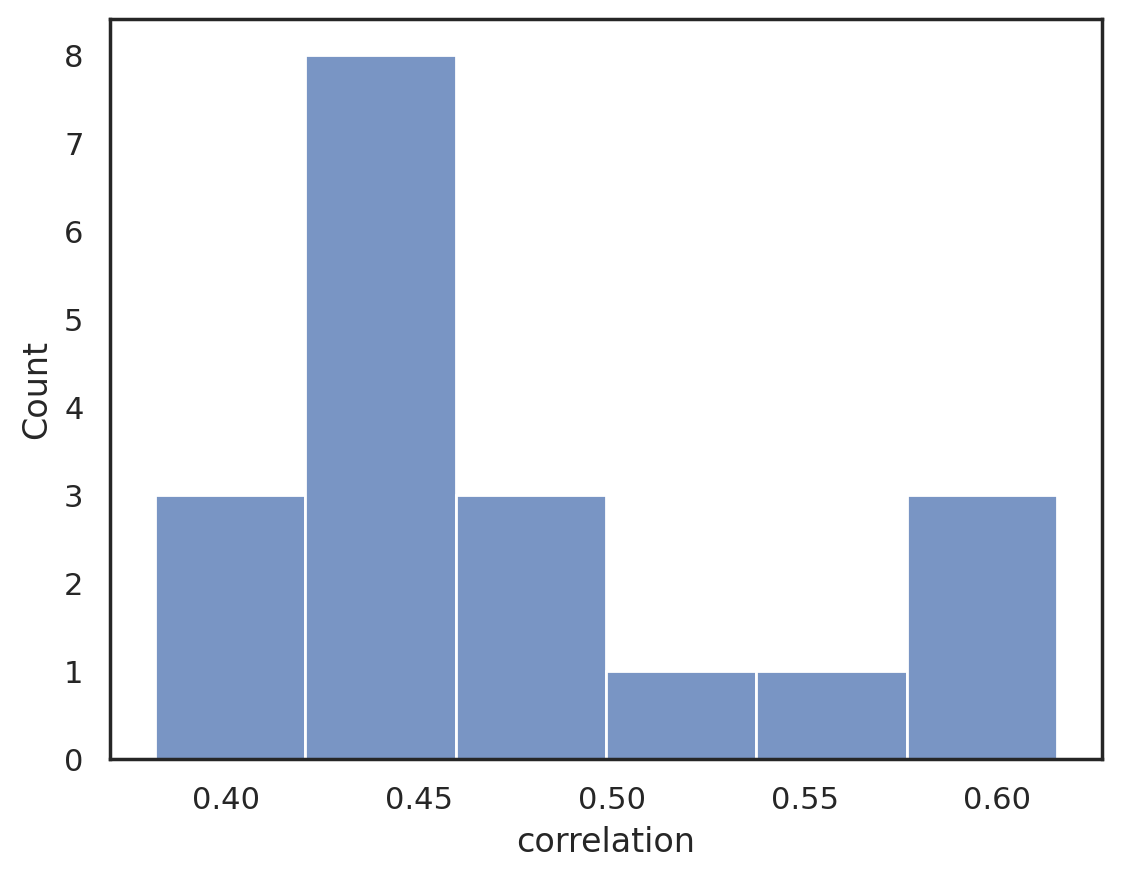

In [34]:
sns.histplot(data=corr_df.loc[corr_df.PDGP_ID.isin(east_yellow_IDs)], x="correlation")

In [52]:
meta_data_samples.Origin.unique()

array(['Mikumi, Tanzania', 'Aberdare, Kenya', 'Chunga, Zambia', 'captive',
       'Awash, Ethiopia', 'Serengeti, Tanzania', 'Arusha, Tanzania',
       'Ngorongoro, Tanzania', 'Ruaha, Tanzania', 'Gombe, Tanzania',
       'Udzungwa, Tanzania', 'Mahale, Tanzania', 'Katavi, Tanzania',
       'Selous, Tanzania', 'Lake Manyara, Tanzania',
       'Tarangire, Tanzania', 'Niokolo-Koba, Senegal',
       'Issa Valley, Tanzania', 'Dendro Park, Zambia', 'Filoha, Ethiopia',
       'Gog Woreda, Gambella region, Ethiopia'], dtype=object)

In [73]:
olive_IDs_subset = meta_data_samples.loc[meta_data_samples.Origin.isin(["Serengeti, Tanzania",
                                                                       'Arusha, Tanzania',
                                                                       'Lake Manyara, Tanzania',
                                                                       'Ngorongoro, Tanzania'])].PGDP_ID
east_yellow_IDs = meta_data_samples.loc[meta_data_samples.C_origin == "Cynocephalus, Central Tanzania"].PGDP_ID

In [74]:
olive_df_rf = window_df_rf.loc[window_df_rf.PDGP_ID.isin(olive_IDs_subset)]
p_north_olive = olive_df_rf.groupby(["windows"]).mean().reset_index().percent_north

In [75]:
yellow_df_rf = window_df_rf.loc[window_df_rf.PDGP_ID.isin(east_yellow_IDs)]
p_north_yellow = yellow_df_rf.groupby(["windows"]).mean().reset_index().percent_north

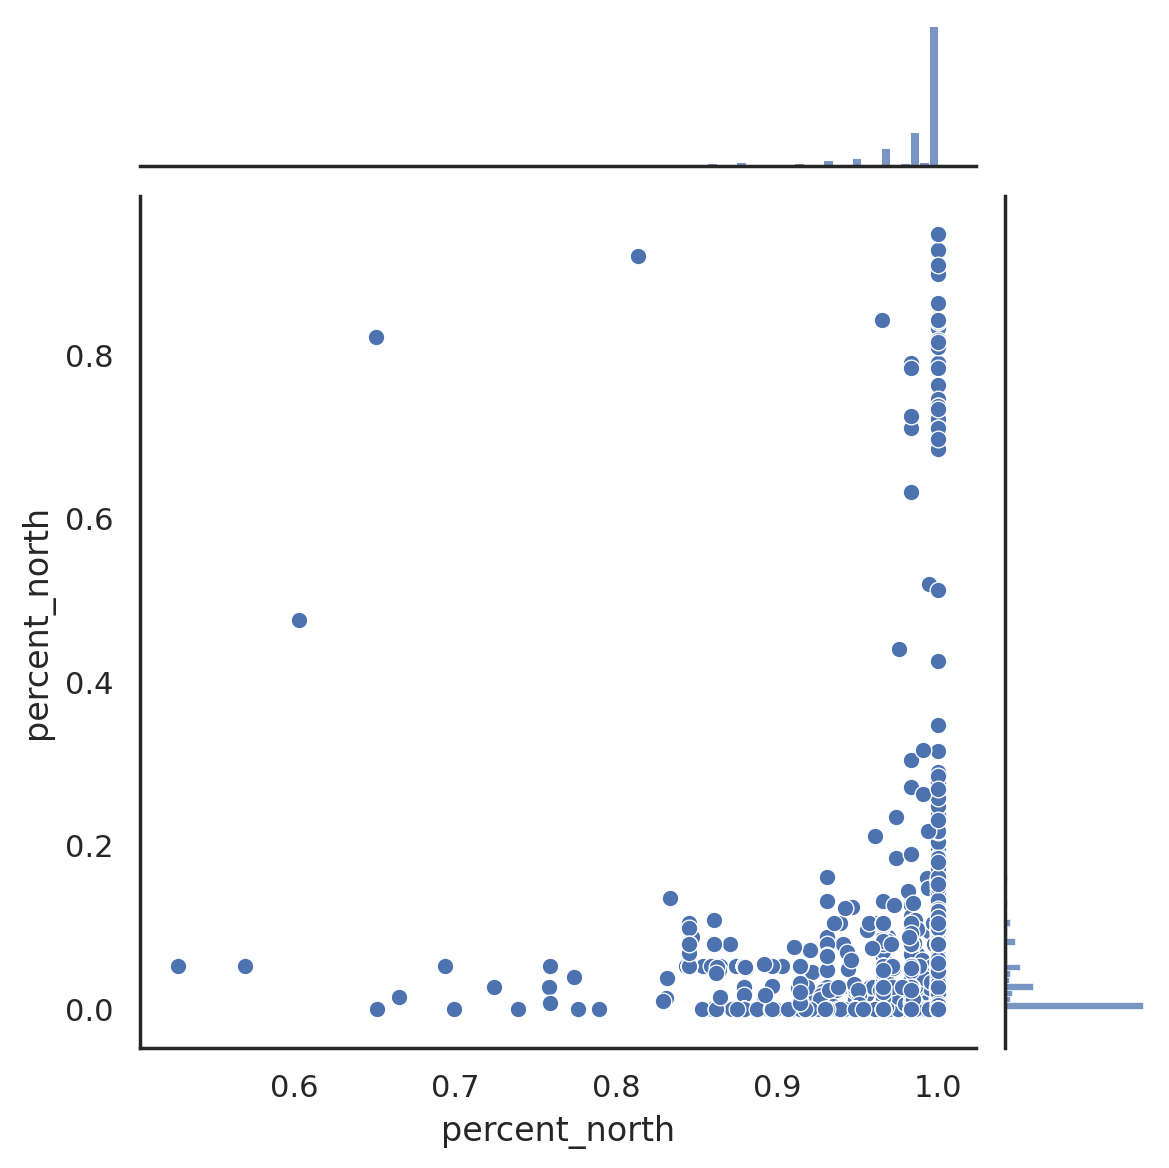

In [84]:
sns.jointplot(x=p_north_olive, y=p_north_yellow)

<AxesSubplot:xlabel='percent_north', ylabel='Count'>

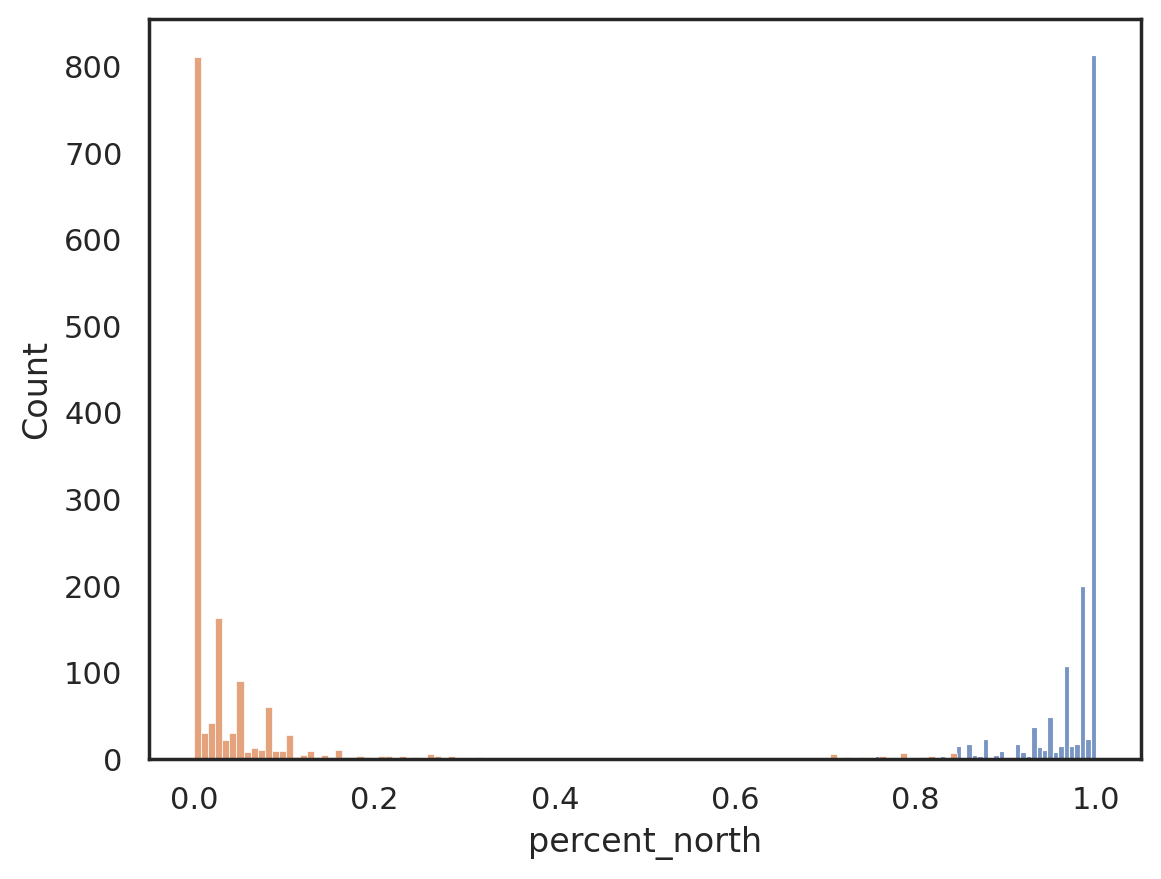

In [82]:
sns.histplot(p_north_olive)
sns.histplot(p_north_yellow)

In [76]:
from scipy.stats.stats import spearmanr   
spearmanr(p_north_olive, p_north_yellow)

SpearmanrResult(correlation=-0.12179082870181082, pvalue=3.6558112825459905e-06)

In [153]:
p_north_yellow.to_csv("../steps/relate_coal_ordering/yellow_northern_percentage.txt")

Checking recombination

In [88]:
recomb_map_path = "/home/eriks/baboondiversity/data/PG_panu3_recombination_map/genetic_map_chr{}.txt"
window_size = 100000
df_l = []
for chrom in ["X"]:
    print(chrom)
    windows_length = {}
    input_temp = window_df_rf# = window_df_rf.loc[window_df_rf.chrom == chrom]
    recomb_map = pd.read_csv(recomb_map_path.format(chrom), sep=" ")
    windows = sorted(input_temp["windows"].unique())
    for window in windows[:-1]:
        windows_length[window] =(recomb_map.loc[recomb_map.position >= window+window_size]["Genetic_Map(cM)"].iloc[0]-
                                 recomb_map.loc[recomb_map.position >= window]["Genetic_Map(cM)"].iloc[0])
    windows_length[windows[-1]] = (recomb_map["Genetic_Map(cM)"].iloc[-2] - 
                            recomb_map.loc[recomb_map.position >= window]["Genetic_Map(cM)"].iloc[0])
    input_temp["cM"] = input_temp["windows"].map(windows_length)
    df_l.append(input_temp)
recomb_df = pd.concat(df_l)

X


In [95]:
cM_df = recomb_df.groupby(["windows"]).mean()

<AxesSubplot:xlabel='windows', ylabel='cM'>

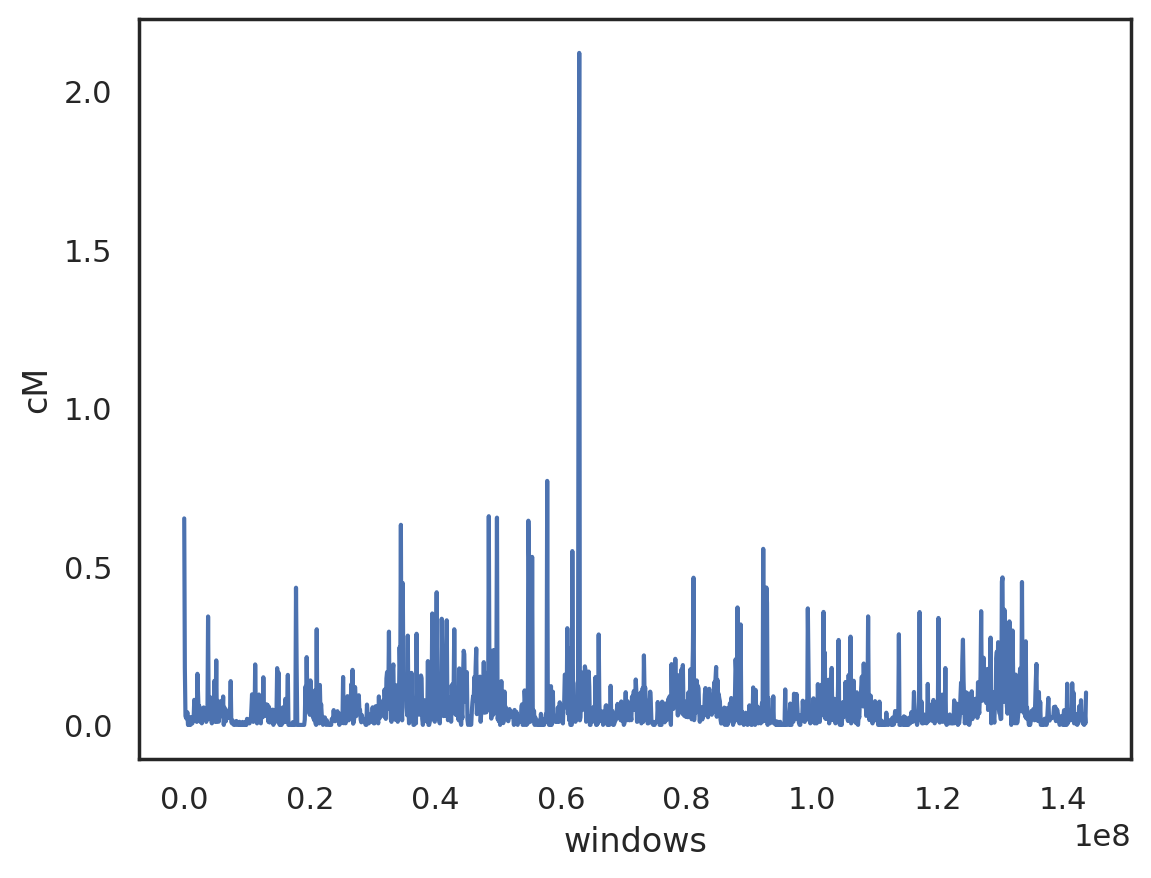

In [99]:
sns.lineplot(cM_df, y="cM", x="windows")

In [118]:
recomb_df["Origin"] = recomb_df.PDGP_ID.map(dict(zip(meta_data_samples.PGDP_ID, meta_data_samples.Origin)))

In [142]:
input_df = recomb_df.groupby(["Origin", "windows"]).mean().reset_index()
df_l = []
for chrom in ["X"]:
    bins = 5
    input_df["recomb_group"] = pd.qcut(input_df["cM"], bins, labels=False, duplicates="drop")
    df_l.append(input_df)
df_all = pd.concat(df_l)

In [143]:
df_all

,Origin,windows,"Hamadryas, Ethiopia","Kindae, Zambia","Papio, Senegal","Ursinus, Zambia",percent_north,cM,recomb_group
0,"Arusha, Tanzania",37,200000.0,0.0,0.0,0.0,1.0,0.651345,4
1,"Arusha, Tanzania",100037,200000.0,0.0,0.0,0.0,1.0,0.180764,4
2,"Arusha, Tanzania",200037,200000.0,0.0,0.0,0.0,1.0,0.028041,2
3,"Arusha, Tanzania",300037,200000.0,0.0,0.0,0.0,1.0,0.021925,2
4,"Arusha, Tanzania",400037,200000.0,0.0,0.0,0.0,1.0,0.019485,1
...,...,...,...,...,...,...,...,...,...
18676,"Udzungwa, Tanzania",143200037,0.0,200000.0,0.0,0.0,0.0,0.009875,1
18677,"Udzungwa, Tanzania",143300037,0.0,200000.0,0.0,0.0,0.0,0.000032,0
18678,"Udzungwa, Tanzania",143400037,0.0,200000.0,0.0,0.0,0.0,0.034413,2
18679,"Udzungwa, Tanzania",143500037,0.0,200000.0,0.0,0.0,0.0,0.004736,0


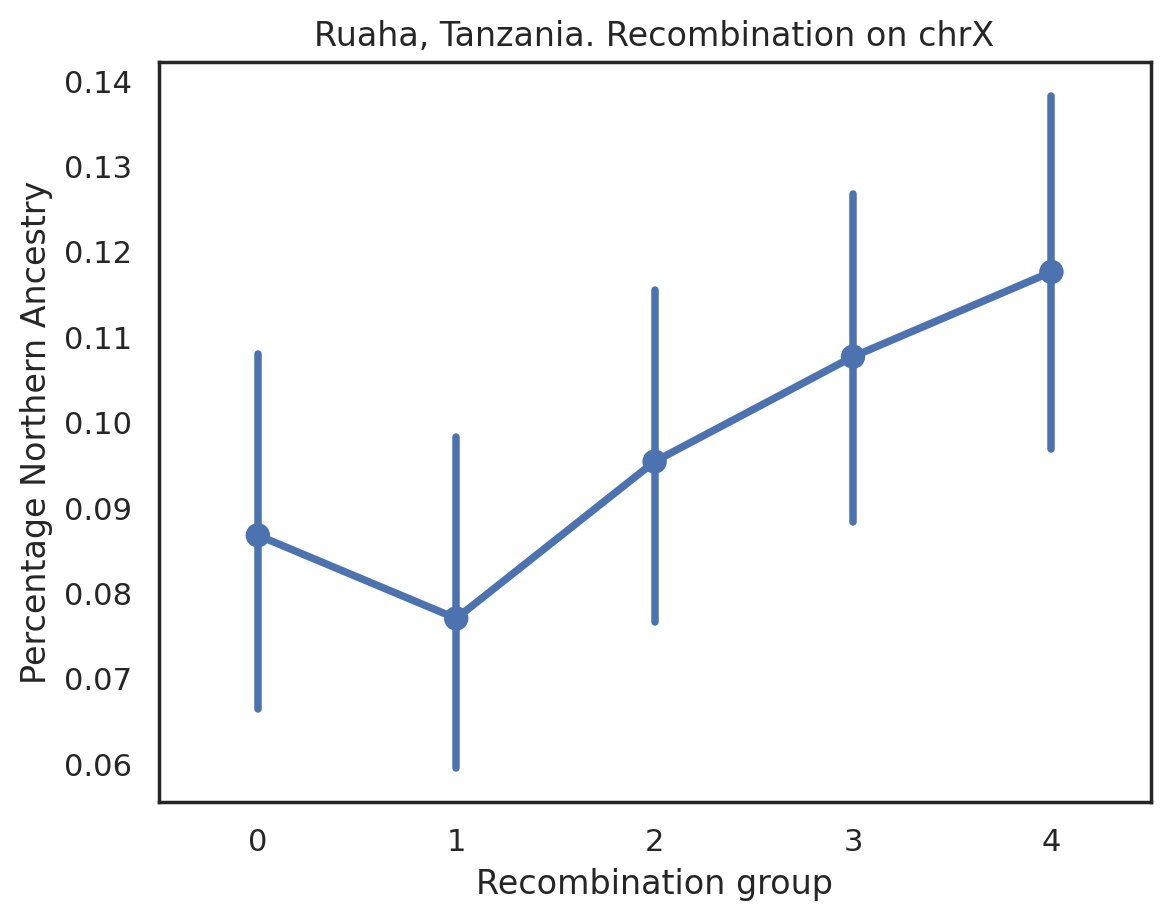

In [150]:
df = df_all.loc[df_all["Origin"] == "Ruaha, Tanzania"]
g = sns.pointplot(data=df, y="percent_north", x="recomb_group", errorbar=('ci', 95))
g.set(title="Ruaha, Tanzania. Recombination on chrX")
g.set(xlabel="Recombination group", ylabel="Percentage Northern Ancestry")
plt.savefig("../figures/ruaha_autosomes_recomb.png", dpi=300, bbox_inches='tight')

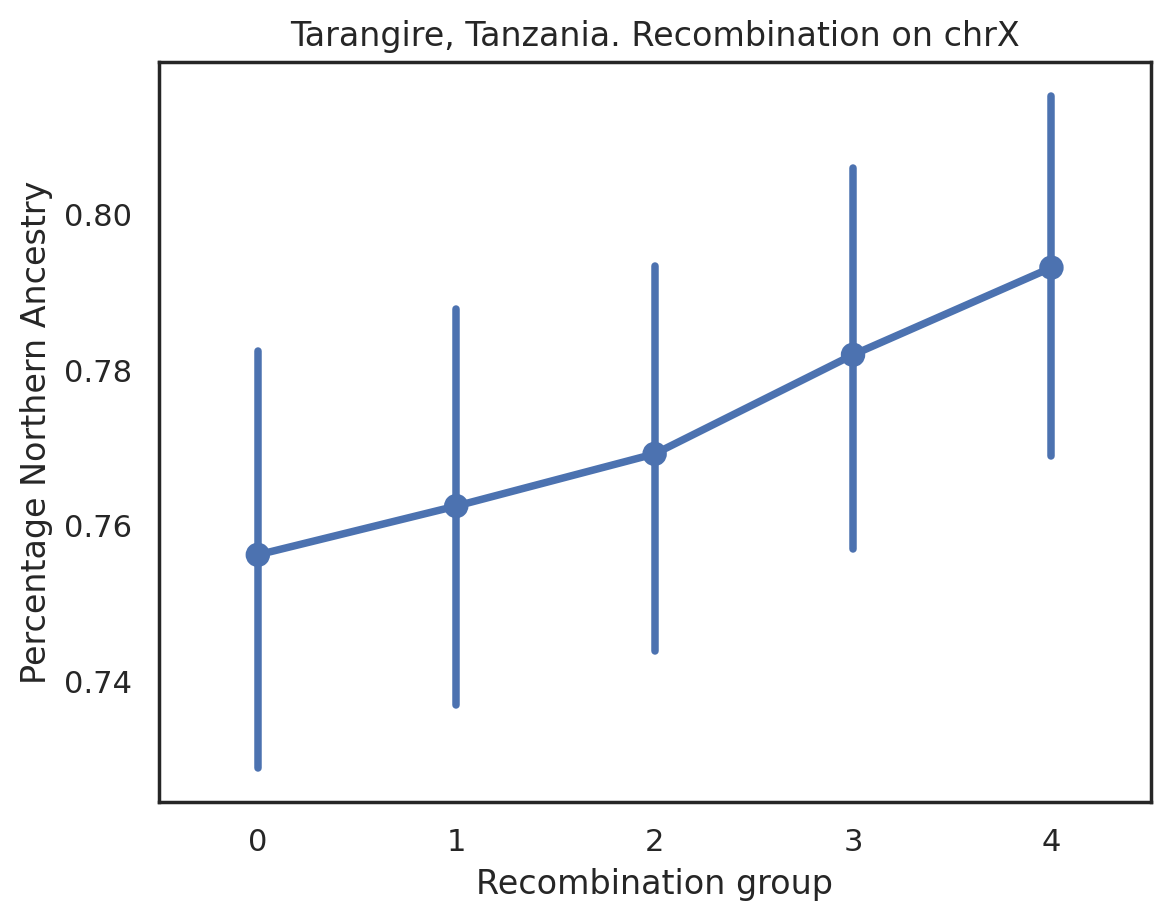

In [151]:
df = df_all.loc[df_all["Origin"] == "Tarangire, Tanzania"]
g = sns.pointplot(data=df, y="percent_north", x="recomb_group", errorbar=('ci', 95))
g.set(title="Tarangire, Tanzania. Recombination on chrX")
g.set(xlabel="Recombination group", ylabel="Percentage Northern Ancestry")
plt.savefig("../figures/tarangire_chrX_rfmix_recomb.png", dpi=300, bbox_inches='tight')